## WeGo Data Introduction

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

In [15]:
wego = pd.read_csv("Headway Data, 8-1-2023 to 9-30-2023.csv")

wego.head()

,CALENDAR_ID,SERVICE_ABBR,ADHERENCE_ID,DATE,ROUTE_ABBR,BLOCK_ABBR,OPERATOR,TRIP_ID,OVERLOAD_ID,ROUTE_DIRECTION_NAME,...,ACTUAL_HDWY,HDWY_DEV,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT,STOP_CANCELLED,PREV_SCHED_STOP_CANCELLED,IS_RELIEF,DWELL_IN_MINS,SCHEDULED_LAYOVER_MINUTES
0,120230801,1,99457890,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,6.500000,NaN
1,120230801,1,99457891,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.000000,NaN
2,120230801,1,99457892,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.000000,NaN
3,120230801,1,99457893,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,NaN,0,0.000000,NaN
4,120230801,1,99457894,2023-08-01,22,2200,1040,345105,0,FROM DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,12.866666,5.0


In [16]:
wego.columns

Index(['CALENDAR_ID', 'SERVICE_ABBR', 'ADHERENCE_ID', 'DATE', 'ROUTE_ABBR',
       'BLOCK_ABBR', 'OPERATOR', 'TRIP_ID', 'OVERLOAD_ID',
       'ROUTE_DIRECTION_NAME', 'TIME_POINT_ABBR', 'ROUTE_STOP_SEQUENCE',
       'TRIP_EDGE', 'LATITUDE', 'LONGITUDE', 'SCHEDULED_TIME',
       'ACTUAL_ARRIVAL_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE',
       'SCHEDULED_HDWY', 'ACTUAL_HDWY', 'HDWY_DEV', 'ADJUSTED_EARLY_COUNT',
       'ADJUSTED_LATE_COUNT', 'ADJUSTED_ONTIME_COUNT', 'STOP_CANCELLED',
       'PREV_SCHED_STOP_CANCELLED', 'IS_RELIEF', 'DWELL_IN_MINS',
       'SCHEDULED_LAYOVER_MINUTES'],
      dtype='object')

In the data, the bus route can be identified by its ROUTE_ABBR value.  
**3:** West End  
**7:** Hillsboro  
**22:** Bordeaux  
**23:** Dickerson Pike  
**50:** Charlotte Pike  
**52:** Nolensville Pike  
**55:** Murfreesboro Pike  
**56:** Gallatin Pike

In [17]:
wego['ROUTE_ABBR'].value_counts().sort_index()

ROUTE_ABBR
3     47162
7     18026
22    25959
23    42108
50    43291
52    51819
55    61944
56    60020
Name: count, dtype: int64

The trip can be identified by the DATE/CALENDAR_ID plus the TRIP_ID.  
**Warning:** The TRIP_ID refers to the route and time but will be used across multiple days.

The data contains multiple **time points** for each trip. There are more stops along the route than time points, but the time points are the points with specific scheduled times the bus operators must adhere to.

The first stop of a trip has a TRIP_EDGE of 1, the last has a TRIP_EDGE of 2, and the intermediate stops are TRIP_EDGE 0. 

Here is the first trip in the dataset. It was a Bordeaux route (Route 22), scheduled to start at 4:42:00 and end at 5:10:00.

In [18]:
wego[['DATE', 'CALENDAR_ID', 'TRIP_ID', 'ROUTE_ABBR', 'TIME_POINT_ABBR', 'TRIP_EDGE', 'SCHEDULED_TIME']].loc[:3]

,DATE,CALENDAR_ID,TRIP_ID,ROUTE_ABBR,TIME_POINT_ABBR,TRIP_EDGE,SCHEDULED_TIME
0,2023-08-01,120230801,345104,22,MHSP,1,2023-08-01 04:42:00
1,2023-08-01,120230801,345104,22,ELIZ,0,2023-08-01 04:46:00
2,2023-08-01,120230801,345104,22,CV23,0,2023-08-01 04:54:00
3,2023-08-01,120230801,345104,22,MCC5_10,2,2023-08-01 05:10:00


Note that the same TRIP_ID appears on the following day.

In [19]:
(
    wego
    .loc[wego['DATE'].astype(str).isin(['2023-08-01', '2023-08-02'])]
    .loc[wego['TRIP_ID'] == 345104]
    [['DATE', 'ROUTE_ABBR', 'TRIP_ID', 'TIME_POINT_ABBR', 'TRIP_EDGE', 'ROUTE_DIRECTION_NAME', 'SCHEDULED_TIME', 'ROUTE_STOP_SEQUENCE']]
)

,DATE,ROUTE_ABBR,TRIP_ID,TIME_POINT_ABBR,TRIP_EDGE,ROUTE_DIRECTION_NAME,SCHEDULED_TIME,ROUTE_STOP_SEQUENCE
0,2023-08-01,22,345104,MHSP,1,TO DOWNTOWN,2023-08-01 04:42:00,14.0
1,2023-08-01,22,345104,ELIZ,0,TO DOWNTOWN,2023-08-01 04:46:00,10.0
2,2023-08-01,22,345104,CV23,0,TO DOWNTOWN,2023-08-01 04:54:00,5.0
3,2023-08-01,22,345104,MCC5_10,2,TO DOWNTOWN,2023-08-01 05:10:00,1.0
6461,2023-08-02,22,345104,MHSP,1,TO DOWNTOWN,2023-08-02 04:42:00,14.0
6462,2023-08-02,22,345104,ELIZ,0,TO DOWNTOWN,2023-08-02 04:46:00,10.0
6463,2023-08-02,22,345104,CV23,0,TO DOWNTOWN,2023-08-02 04:54:00,5.0
6464,2023-08-02,22,345104,MCC5_10,2,TO DOWNTOWN,2023-08-02 05:10:00,1.0


**Adherence** refers to the difference between scheduled time and the actual time that the bus departs from a stop.

A negative value for ADHERENCE indicates that the bus is late, and a positive indicates that the bus is early.

Generally, an adherence value less than -6 is considered late, and greater than 1 is considered early, but there are some exceptions. For example, a positive adherence for the end of a trip (TRIP_EDGE 2) is not considered early, since it is not a problem if a bus ends its trip early as long as it didn't pass other timepoints early along the way. You can check whether a trip was considered on-time, early, or late using the ADJUSTED_EARLY_COUNT, ADJUSTED_LATE_COUNT, and ADJUSTED_ONTIME_COUNT columns.

Here is an example of a trip where all time points would be considered to be on time. Notice that at the end of the trip, the bus was more than 6 minutes early, but was still counted as on-time since this was a trip edge of 2.

In [20]:
(
    wego
    [[
        'DATE', 'CALENDAR_ID', 'TRIP_ID', 'ROUTE_ABBR',
        'TIME_POINT_ABBR', 'TRIP_EDGE',
        'SCHEDULED_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE',
        'ADJUSTED_EARLY_COUNT', 'ADJUSTED_LATE_COUNT', 'ADJUSTED_ONTIME_COUNT'
    ]]
    .loc[:3]
)

,DATE,CALENDAR_ID,TRIP_ID,ROUTE_ABBR,TIME_POINT_ABBR,TRIP_EDGE,SCHEDULED_TIME,ACTUAL_DEPARTURE_TIME,ADHERENCE,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT
0,2023-08-01,120230801,345104,22,MHSP,1,2023-08-01 04:42:00,2023-08-01 04:44:08,-2.133333,0,0,1
1,2023-08-01,120230801,345104,22,ELIZ,0,2023-08-01 04:46:00,2023-08-01 04:48:27,-2.450000,0,0,1
2,2023-08-01,120230801,345104,22,CV23,0,2023-08-01 04:54:00,2023-08-01 04:54:56,-0.933333,0,0,1
3,2023-08-01,120230801,345104,22,MCC5_10,2,2023-08-01 05:10:00,2023-08-01 05:03:43,6.283333,0,0,1


And one that has one late stop.

In [21]:
(
    wego
    [[
        'DATE', 'CALENDAR_ID', 'TRIP_ID', 'ROUTE_ABBR',
        'TIME_POINT_ABBR', 'TRIP_EDGE',
        'SCHEDULED_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE',
        'ADJUSTED_EARLY_COUNT', 'ADJUSTED_LATE_COUNT', 'ADJUSTED_ONTIME_COUNT'
    ]]
    .loc[77:79]
)

,DATE,CALENDAR_ID,TRIP_ID,ROUTE_ABBR,TIME_POINT_ABBR,TRIP_EDGE,SCHEDULED_TIME,ACTUAL_DEPARTURE_TIME,ADHERENCE,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT
77,2023-08-01,120230801,345127,22,MHSP,1,2023-08-01 17:05:00,2023-08-01 17:08:21,-3.350000,0,0,1
78,2023-08-01,120230801,345127,22,CV23,0,2023-08-01 17:14:00,2023-08-01 17:20:10,-6.166666,0,1,0
79,2023-08-01,120230801,345127,22,MCC5_10,2,2023-08-01 17:30:00,2023-08-01 17:30:23,-0.383333,0,0,1


And one which was early.

In [22]:
(
    wego
    [[
        'DATE', 'CALENDAR_ID', 'TRIP_ID', 'ROUTE_ABBR',
        'TIME_POINT_ABBR', 'TRIP_EDGE',
        'SCHEDULED_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE',
        'ADJUSTED_EARLY_COUNT', 'ADJUSTED_LATE_COUNT', 'ADJUSTED_ONTIME_COUNT'
    ]]
    .loc[11:13]
)

,DATE,CALENDAR_ID,TRIP_ID,ROUTE_ABBR,TIME_POINT_ABBR,TRIP_EDGE,SCHEDULED_TIME,ACTUAL_DEPARTURE_TIME,ADHERENCE,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT
11,2023-08-01,120230801,345107,22,MCC5_10,1,2023-08-01 06:15:00,2023-08-01 06:16:19,-1.316666,0,0,1
12,2023-08-01,120230801,345107,22,CV23,0,2023-08-01 06:25:00,2023-08-01 06:23:30,1.500000,1,0,0
13,2023-08-01,120230801,345107,22,MHSP,2,2023-08-01 06:35:00,2023-08-01 06:30:59,4.016666,0,0,1


**Headway** is the amount of time between a bus and the prior bus at the same stop. In the dataset, the amount of headway scheduled is contained in the SCHEDULED_HDWY column and indicates the difference between the scheduled time for a particular stop and the scheduled time for the previous bus on that same stop.

This dataset contains a column HDWY_DEV, which shows the amount of deviation from the scheduled headway. **Bunching** occurs when there is shorter headway than scheduled, which would appear as a negative HDWY_DEV value. **Gapping** is when there is more headway than scheduled and appears as a positive value in the HDWY_DEV column. Note that you can calculate headway deviation percentage as HDWY_DEV/SCHEDULED_HDWY. 

The generally accepted range of headway deviation is 50% to 150% of the scheduled headway, so if scheduled headway is 10 minutes, a headway deviation of up to 5 minutes would be acceptable (but not ideal).

In [23]:
(
    wego
    .loc[wego['ROUTE_ABBR'] == 22]
    .loc[wego['ROUTE_DIRECTION_NAME'] == 'TO DOWNTOWN']
    .loc[wego['TIME_POINT_ABBR'] == 'CV23']
    [['DATE', 'TRIP_ID', 'TIME_POINT_ABBR','ROUTE_DIRECTION_NAME', 'TRIP_EDGE', 
      'SCHEDULED_TIME', 'SCHEDULED_HDWY',
      'ACTUAL_DEPARTURE_TIME', 'ACTUAL_HDWY', 'HDWY_DEV'
     ]]
    .sort_values(['DATE', 'SCHEDULED_TIME'])
    .iloc[:5]
)

,DATE,TRIP_ID,TIME_POINT_ABBR,ROUTE_DIRECTION_NAME,TRIP_EDGE,SCHEDULED_TIME,SCHEDULED_HDWY,ACTUAL_DEPARTURE_TIME,ACTUAL_HDWY,HDWY_DEV
2,2023-08-01,345104,CV23,TO DOWNTOWN,0,2023-08-01 04:54:00,NaN,2023-08-01 04:54:56,NaN,NaN
126,2023-08-01,345213,CV23,TO DOWNTOWN,0,2023-08-01 05:19:00,25.0,2023-08-01 05:18:59,24.050000,-0.950000
402,2023-08-01,345405,CV23,TO DOWNTOWN,0,2023-08-01 05:39:00,20.0,2023-08-01 05:39:40,20.683333,0.683333
9,2023-08-01,345106,CV23,TO DOWNTOWN,0,2023-08-01 05:54:00,15.0,2023-08-01 05:54:11,14.516666,-0.483334
316,2023-08-01,345377,CV23,TO DOWNTOWN,0,2023-08-01 06:09:00,15.0,2023-08-01 06:10:01,15.833333,0.833333


Two other columns that you've been asked to explore are the DWELL_IN_MINS column and SCHEDULED_LAYOVER_MINUTES, which shows the difference between actual arrival and actual departure time at a time point and the time a bus was scheduled to arrive at the time point and when it is scheduled to leave at the beginning of a trip.

Here, we can see the end of the first trip in the dataset and the beginning of the next trip, which goes in the opposite direction.

In [24]:
wego.loc[3:4, ['DATE', 'TRIP_ID', 'TRIP_EDGE', 'TIME_POINT_ABBR',
               'ACTUAL_ARRIVAL_TIME', 'ACTUAL_DEPARTURE_TIME', 'DWELL_IN_MINS', 'SCHEDULED_LAYOVER_MINUTES']]

,DATE,TRIP_ID,TRIP_EDGE,TIME_POINT_ABBR,ACTUAL_ARRIVAL_TIME,ACTUAL_DEPARTURE_TIME,DWELL_IN_MINS,SCHEDULED_LAYOVER_MINUTES
3,2023-08-01,345104,2,MCC5_10,2023-08-01 05:03:43,2023-08-01 05:03:43,0.000000,NaN
4,2023-08-01,345105,1,MCC5_10,2023-08-01 05:03:43,2023-08-01 05:16:35,12.866666,5.0


What is the overall on-time performance, and what do the overall distribution of adherence look like?

Extreme outliers removed from plot: 303 rows
── On-time Performance (1/5 rule, minutes) ──────
  Total records : 338,528
  Early  (<-1 min) : 218,134  (64.4%)
  On-time        : 114,956  (34.0%)
  Late   (>5 min)  : 5,438  (1.6%)
  Mean adherence : -3.09 min
  Median         : -2.00 min


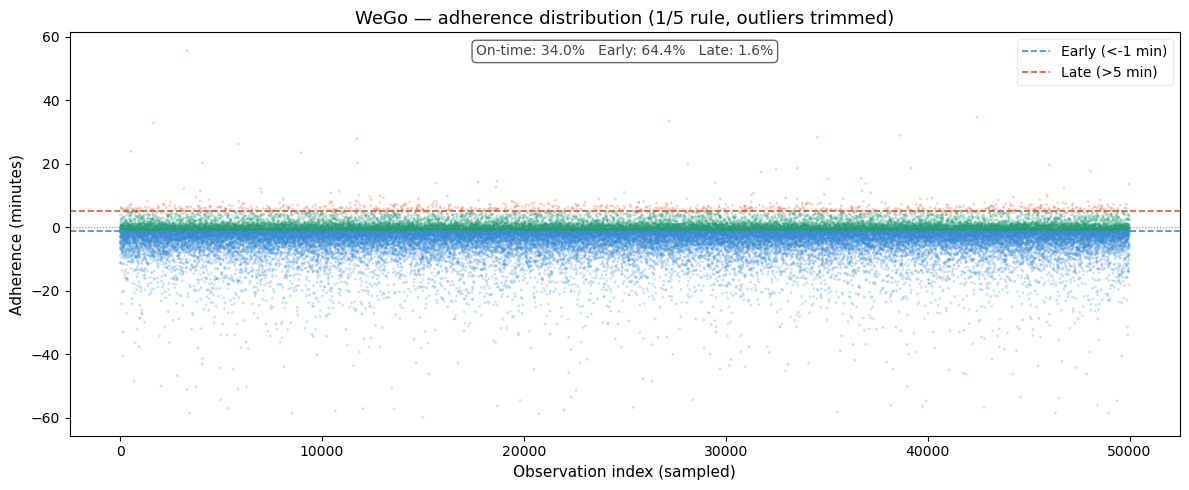

In [27]:
early_thresh = -1   # more than 1 min early
late_thresh  =  5   # more than 5 min late

# Trim extreme outliers for display (keep for stats separately)
outliers = wego[wego["ADHERENCE"] < -60]
print(f"Extreme outliers removed from plot: {len(outliers):,} rows")

wego_clean = wego[wego["ADHERENCE"].between(-60, 60)]
total  = len(wego_clean)
early  = (wego_clean["ADHERENCE"] < early_thresh).sum()
ontime = wego_clean["ADHERENCE"].between(early_thresh, late_thresh).sum()
late   = (wego_clean["ADHERENCE"] > late_thresh).sum()

print("── On-time Performance (1/5 rule, minutes) ──────")
print(f"  Total records : {total:,}")
print(f"  Early  (<{early_thresh} min) : {early:,}  ({early/total:.1%})")
print(f"  On-time        : {ontime:,}  ({ontime/total:.1%})")
print(f"  Late   (>{late_thresh} min)  : {late:,}  ({late/total:.1%})")
print(f"  Mean adherence : {wego_clean['ADHERENCE'].mean():.2f} min")
print(f"  Median         : {wego_clean['ADHERENCE'].median():.2f} min")

# ── Scatterplot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

sample = wego_clean.sample(min(50_000, total), random_state=42)

colors = np.where(sample["ADHERENCE"] < early_thresh, "#3B8BD4",
         np.where(sample["ADHERENCE"] > late_thresh,  "#D85A30", "#1D9E75"))

ax.scatter(range(len(sample)), sample["ADHERENCE"],
           c=colors, alpha=0.25, s=4, linewidths=0)

ax.axhline(early_thresh, color="#3B8BD4", lw=1.2, ls="--", label=f"Early (<{early_thresh} min)")
ax.axhline(0,            color="#888780", lw=0.8, ls=":")
ax.axhline(late_thresh,  color="#D85A30", lw=1.2, ls="--", label=f"Late (>{late_thresh} min)")

ax.set_xlabel("Observation index (sampled)", fontsize=11)
ax.set_ylabel("Adherence (minutes)", fontsize=11)
ax.set_title("WeGo — adherence distribution (1/5 rule, outliers trimmed)", fontsize=13, fontweight="medium")
ax.legend(fontsize=10, framealpha=0.4)

summary = f"On-time: {ontime/total:.1%}   Early: {early/total:.1%}   Late: {late/total:.1%}"
ax.text(0.5, 0.97, summary, transform=ax.transAxes,
        ha="center", va="top", fontsize=10, color="#444441",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.6))

plt.tight_layout()
plt.savefig("wego_adherence_scatter.png", dpi=150)
plt.show()

How does direction of travel, route, or location affect the on-time performance?

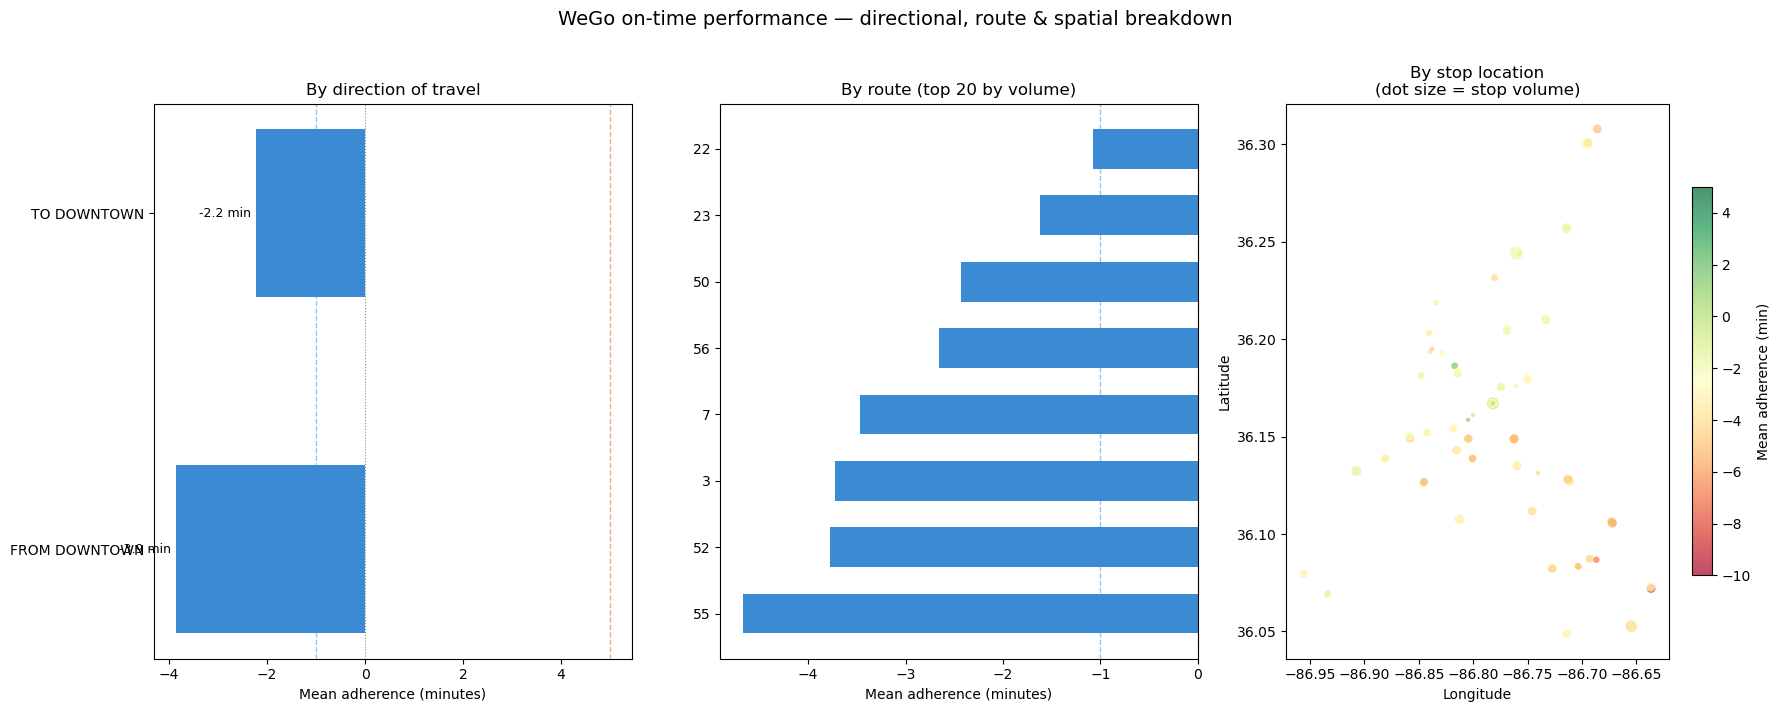

In [29]:
early_thresh = -1
late_thresh  =  5

wego_clean = wego[wego["ADHERENCE"].between(-60, 60)].copy()

def otp_stats(group):
    n = len(group)
    return pd.Series({
        "n":         n,
        "early_pct": (group["ADHERENCE"] < early_thresh).sum() / n * 100,
        "ontime_pct": group["ADHERENCE"].between(early_thresh, late_thresh).sum() / n * 100,
        "late_pct":  (group["ADHERENCE"] > late_thresh).sum() / n * 100,
        "mean_adh":  group["ADHERENCE"].mean(),
    })

# ── 1. Direction of travel ─────────────────────────────────────────────────────
dir_stats = (
    wego_clean.groupby("ROUTE_DIRECTION_NAME")
    .apply(otp_stats, include_groups=False)
    .reset_index()
)

route_stats = (
    wego_clean.groupby("ROUTE_ABBR")
    .apply(otp_stats, include_groups=False)
    .reset_index()
    .sort_values("n", ascending=False)
    .head(20)
    .sort_values("mean_adh")
)

stop_stats = (
    wego_clean.groupby(["TIME_POINT_ABBR", "LATITUDE", "LONGITUDE"])
    .apply(otp_stats, include_groups=False)
    .reset_index()
    .query("n >= 50")
)
# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# — Plot 1: Direction — horizontal bar
ax = axes[0]
dirs = dir_stats.sort_values("mean_adh")
colors_dir = ["#3B8BD4" if v < 0 else "#D85A30" for v in dirs["mean_adh"]]
bars = ax.barh(dirs["ROUTE_DIRECTION_NAME"], dirs["mean_adh"], color=colors_dir, height=0.5)
ax.axvline(0, color="#888780", lw=0.8, ls=":")
ax.axvline(early_thresh, color="#3B8BD4", lw=1, ls="--", alpha=0.5)
ax.axvline(late_thresh,  color="#D85A30", lw=1, ls="--", alpha=0.5)
ax.set_xlabel("Mean adherence (minutes)")
ax.set_title("By direction of travel", fontsize=12, fontweight="medium")
for bar, val in zip(bars, dirs["mean_adh"]):
    ax.text(val - 0.1 if val < 0 else val + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f} min", va="center", ha="right" if val < 0 else "left", fontsize=9)

# — Plot 2: Route — horizontal bar (top 20)
ax = axes[1]
colors_route = ["#3B8BD4" if v < 0 else "#D85A30" for v in route_stats["mean_adh"]]
ax.barh(route_stats["ROUTE_ABBR"].astype(str), route_stats["mean_adh"],
        color=colors_route, height=0.6)
ax.axvline(0, color="#888780", lw=0.8, ls=":")
ax.axvline(early_thresh, color="#3B8BD4", lw=1, ls="--", alpha=0.5)
ax.set_xlabel("Mean adherence (minutes)")
ax.set_title("By route (top 20 by volume)", fontsize=12, fontweight="medium")

# — Plot 3: Location scatter map
ax = axes[2]
sc = ax.scatter(
    stop_stats["LONGITUDE"],
    stop_stats["LATITUDE"],
    c=stop_stats["mean_adh"],
    cmap="RdYlGn",        # red = early, green = on-time/late
    vmin=-10, vmax=5,
    s=stop_stats["n"] / stop_stats["n"].max() * 80 + 10,
    alpha=0.7, linewidths=0
)
plt.colorbar(sc, ax=ax, label="Mean adherence (min)", shrink=0.7)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("By stop location\n(dot size = stop volume)", fontsize=12, fontweight="medium")

plt.suptitle("WeGo on-time performance — directional, route & spatial breakdown",
             fontsize=14, fontweight="medium", y=1.01)
plt.tight_layout()
plt.savefig("wego_otp_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

How does time of day or day of week affect on-time performance?

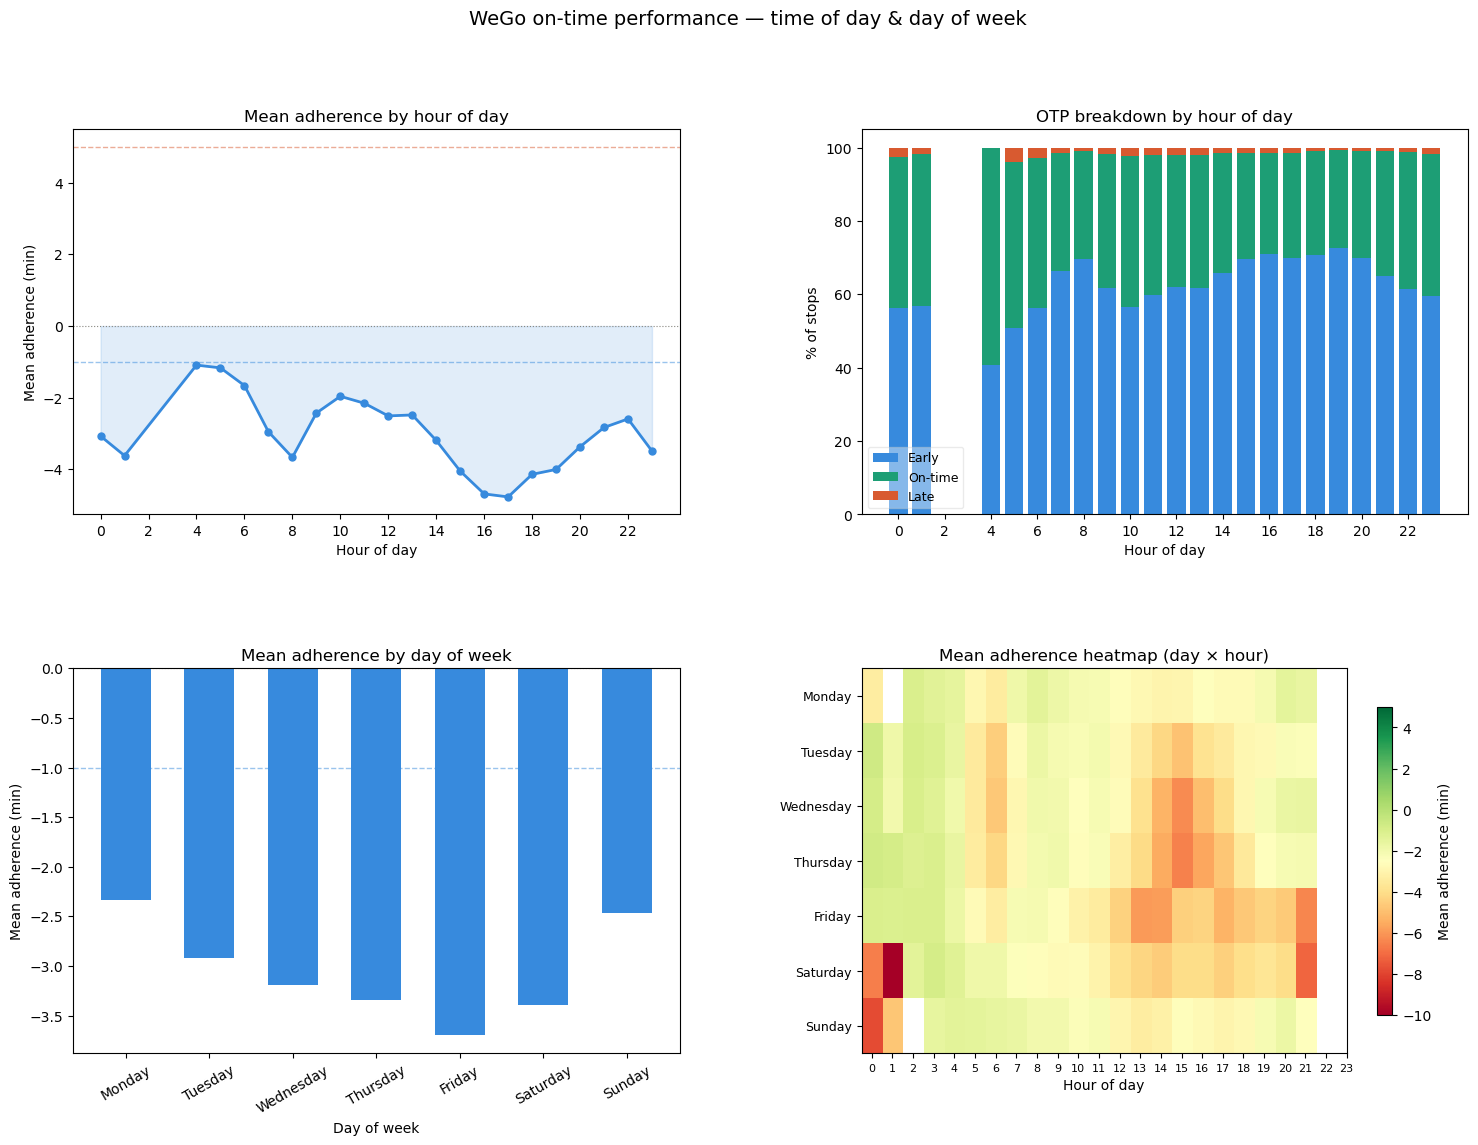

In [30]:

early_thresh = -1
late_thresh  =  5

wego_clean = wego[wego["ADHERENCE"].between(-60, 60)].copy()

# Parse time fields
wego_clean["SCHEDULED_TIME"] = pd.to_datetime(wego_clean["SCHEDULED_TIME"])
wego_clean["hour"] = wego_clean["SCHEDULED_TIME"].dt.hour
wego_clean["dow"]  = wego_clean["SCHEDULED_TIME"].dt.dayofweek  # 0=Mon, 6=Sun
wego_clean["dow_name"] = wego_clean["SCHEDULED_TIME"].dt.day_name()

def otp_stats(group):
    n = len(group)
    return pd.Series({
        "n":         n,
        "early_pct": (group["ADHERENCE"] < early_thresh).sum() / n * 100,
        "ontime_pct": group["ADHERENCE"].between(early_thresh, late_thresh).sum() / n * 100,
        "late_pct":  (group["ADHERENCE"] > late_thresh).sum() / n * 100,
        "mean_adh":  group["ADHERENCE"].mean(),
    })

# ── By hour ───────────────────────────────────────────────────────────────────
hour_stats = (
    wego_clean.groupby("hour")
    .apply(otp_stats, include_groups=False)
    .reset_index()
)

# ── By day of week ────────────────────────────────────────────────────────────
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_stats = (
    wego_clean.groupby("dow_name")
    .apply(otp_stats, include_groups=False)
    .reset_index()
)
dow_stats["dow_name"] = pd.Categorical(dow_stats["dow_name"], categories=dow_order, ordered=True)
dow_stats = dow_stats.sort_values("dow_name")

# ── Heatmap: hour × day of week ───────────────────────────────────────────────
heatmap_data = (
    wego_clean.groupby(["dow_name", "hour"])["ADHERENCE"]
    .mean()
    .unstack("hour")
)
heatmap_data = heatmap_data.reindex(dow_order)

# ── Plots ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.3)

# — Plot 1: Mean adherence by hour (line)
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(hour_stats["hour"], hour_stats["mean_adh"],
         color="#378ADD", lw=2, marker="o", ms=5, zorder=3)
ax1.fill_between(hour_stats["hour"], hour_stats["mean_adh"], 0,
                 where=hour_stats["mean_adh"] < 0,
                 color="#378ADD", alpha=0.15)
ax1.fill_between(hour_stats["hour"], hour_stats["mean_adh"], 0,
                 where=hour_stats["mean_adh"] > 0,
                 color="#D85A30", alpha=0.15)
ax1.axhline(0,            color="#888780", lw=0.8, ls=":")
ax1.axhline(early_thresh, color="#378ADD", lw=1,   ls="--", alpha=0.5)
ax1.axhline(late_thresh,  color="#D85A30", lw=1,   ls="--", alpha=0.5)
ax1.set_xlabel("Hour of day")
ax1.set_ylabel("Mean adherence (min)")
ax1.set_title("Mean adherence by hour of day", fontweight="medium")
ax1.set_xticks(range(0, 24, 2))

# — Plot 2: Stacked % bar by hour (early / on-time / late)
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(hour_stats["hour"], hour_stats["early_pct"],
        color="#378ADD", label="Early", width=0.8)
ax2.bar(hour_stats["hour"], hour_stats["ontime_pct"],
        bottom=hour_stats["early_pct"],
        color="#1D9E75", label="On-time", width=0.8)
ax2.bar(hour_stats["hour"], hour_stats["late_pct"],
        bottom=hour_stats["early_pct"] + hour_stats["ontime_pct"],
        color="#D85A30", label="Late", width=0.8)
ax2.set_xlabel("Hour of day")
ax2.set_ylabel("% of stops")
ax2.set_title("OTP breakdown by hour of day", fontweight="medium")
ax2.set_xticks(range(0, 24, 2))
ax2.legend(fontsize=9, framealpha=0.4)

# — Plot 3: Mean adherence by day of week
ax3 = fig.add_subplot(gs[1, 0])
colors_dow = ["#378ADD" if v < 0 else "#D85A30" for v in dow_stats["mean_adh"]]
ax3.bar(dow_stats["dow_name"], dow_stats["mean_adh"], color=colors_dow, width=0.6)
ax3.axhline(0,            color="#888780", lw=0.8, ls=":")
ax3.axhline(early_thresh, color="#378ADD", lw=1,   ls="--", alpha=0.5)
ax3.set_xlabel("Day of week")
ax3.set_ylabel("Mean adherence (min)")
ax3.set_title("Mean adherence by day of week", fontweight="medium")
ax3.tick_params(axis="x", rotation=30)

# — Plot 4: Heatmap hour × day
ax4 = fig.add_subplot(gs[1, 1])
im = ax4.imshow(heatmap_data.values, aspect="auto", cmap="RdYlGn",
                vmin=-10, vmax=5, interpolation="nearest")
ax4.set_xticks(range(24))
ax4.set_xticklabels(range(24), fontsize=8)
ax4.set_yticks(range(len(dow_order)))
ax4.set_yticklabels(dow_order, fontsize=9)
ax4.set_xlabel("Hour of day")
ax4.set_title("Mean adherence heatmap (day × hour)", fontweight="medium")
plt.colorbar(im, ax=ax4, label="Mean adherence (min)", shrink=0.8)

fig.suptitle("WeGo on-time performance — time of day & day of week",
             fontsize=14, fontweight="medium")
plt.savefig("wego_temporal_otp.png", dpi=150, bbox_inches="tight")
plt.show()

How much of a factor does the driver have on on-time performance? The driver is indicated by the OPERATOR variable.

Operators with ≥50 observations: 299
Mean adherence across operators : -3.24 min
Std of operator means           : 1.98 min
Best operator mean  : -10.52 min
Worst operator mean : 1.30 min
Interquartile range : -4.17 to -1.89 min

Variance explained by operator  : 12.7%


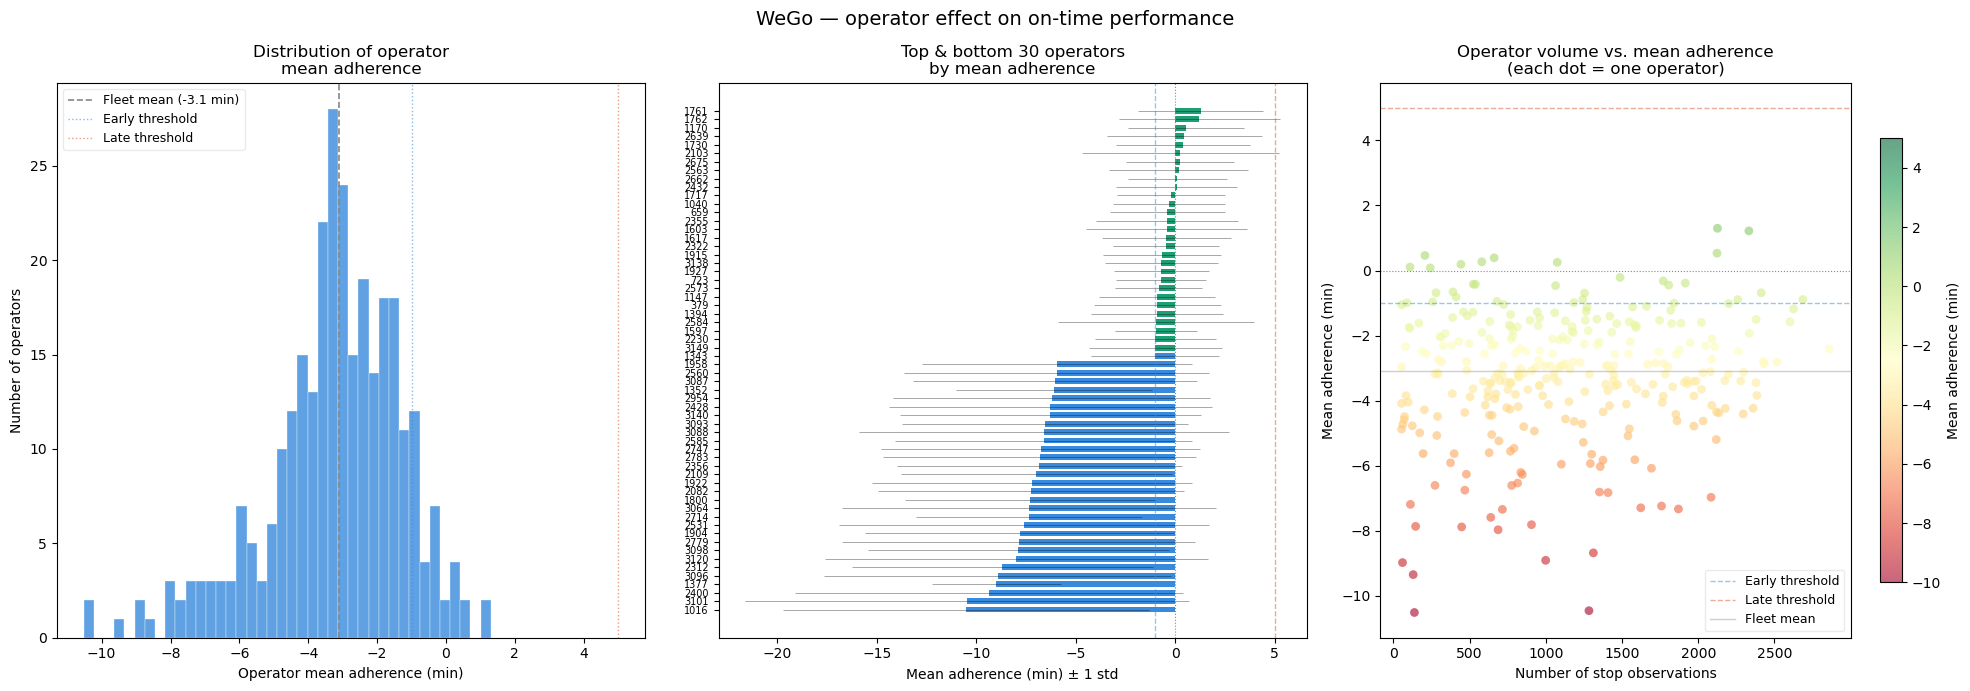

In [31]:


early_thresh = -1
late_thresh  =  5

wego_clean = wego[wego["ADHERENCE"].between(-60, 60)].copy()

def otp_stats(group):
    n = len(group)
    return pd.Series({
        "n":          n,
        "early_pct":  (group["ADHERENCE"] < early_thresh).sum() / n * 100,
        "ontime_pct": group["ADHERENCE"].between(early_thresh, late_thresh).sum() / n * 100,
        "late_pct":   (group["ADHERENCE"] > late_thresh).sum() / n * 100,
        "mean_adh":   group["ADHERENCE"].mean(),
        "std_adh":    group["ADHERENCE"].std(),
    })

# ── By operator ───────────────────────────────────────────────────────────────
op_stats = (
    wego_clean.groupby("OPERATOR")
    .apply(otp_stats, include_groups=False)
    .reset_index()
    .query("n >= 50")        # drop operators with very few observations
    .sort_values("mean_adh")
)

print(f"Operators with ≥50 observations: {len(op_stats)}")
print(f"Mean adherence across operators : {op_stats['mean_adh'].mean():.2f} min")
print(f"Std of operator means           : {op_stats['mean_adh'].std():.2f} min")
print(f"Best operator mean  : {op_stats['mean_adh'].min():.2f} min")
print(f"Worst operator mean : {op_stats['mean_adh'].max():.2f} min")
print(f"Interquartile range : {op_stats['mean_adh'].quantile(0.25):.2f} to {op_stats['mean_adh'].quantile(0.75):.2f} min")

# Variance decomposition — how much of total variance is between operators?
grand_mean = wego_clean["ADHERENCE"].mean()
ss_total   = ((wego_clean["ADHERENCE"] - grand_mean) ** 2).sum()
op_means   = wego_clean.groupby("OPERATOR")["ADHERENCE"].transform("mean")
ss_between = ((op_means - grand_mean) ** 2).sum()
print(f"\nVariance explained by operator  : {ss_between / ss_total * 100:.1f}%")

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# — Plot 1: Distribution of operator mean adherence
ax = axes[0]
ax.hist(op_stats["mean_adh"], bins=40, color="#378ADD", alpha=0.8, edgecolor="white", lw=0.3)
ax.axvline(grand_mean,    color="#888780", lw=1.2, ls="--", label=f"Fleet mean ({grand_mean:.1f} min)")
ax.axvline(early_thresh,  color="#378ADD", lw=1,   ls=":",  alpha=0.6, label="Early threshold")
ax.axvline(late_thresh,   color="#D85A30", lw=1,   ls=":",  alpha=0.6, label="Late threshold")
ax.set_xlabel("Operator mean adherence (min)")
ax.set_ylabel("Number of operators")
ax.set_title("Distribution of operator\nmean adherence", fontweight="medium")
ax.legend(fontsize=9, framealpha=0.4)

# — Plot 2: Ranked operator means with error bars (std), top/bottom 30
ax = axes[1]
n_show = min(30, len(op_stats) // 2)
show = pd.concat([op_stats.head(n_show), op_stats.tail(n_show)]).drop_duplicates()
colors = ["#378ADD" if v < early_thresh else "#D85A30" if v > late_thresh
          else "#1D9E75" for v in show["mean_adh"]]
ax.barh(range(len(show)), show["mean_adh"], color=colors,
        xerr=show["std_adh"], error_kw={"lw": 0.6, "alpha": 0.4}, height=0.7)
ax.axvline(0,            color="#888780", lw=0.8, ls=":")
ax.axvline(early_thresh, color="#378ADD", lw=1,   ls="--", alpha=0.5)
ax.axvline(late_thresh,  color="#D85A30", lw=1,   ls="--", alpha=0.5)
ax.set_yticks(range(len(show)))
ax.set_yticklabels(show["OPERATOR"].astype(str), fontsize=7)
ax.set_xlabel("Mean adherence (min) ± 1 std")
ax.set_title(f"Top & bottom {n_show} operators\nby mean adherence", fontweight="medium")

# — Plot 3: Scatter — operator volume vs mean adherence
ax = axes[2]
sc = ax.scatter(
    op_stats["n"],
    op_stats["mean_adh"],
    c=op_stats["mean_adh"],
    cmap="RdYlGn", vmin=-10, vmax=5,
    s=40, alpha=0.6, linewidths=0
)
ax.axhline(0,            color="#888780", lw=0.8, ls=":")
ax.axhline(early_thresh, color="#378ADD", lw=1,   ls="--", alpha=0.5, label="Early threshold")
ax.axhline(late_thresh,  color="#D85A30", lw=1,   ls="--", alpha=0.5, label="Late threshold")
ax.axhline(grand_mean,   color="#888780", lw=1,   ls="-",  alpha=0.4, label="Fleet mean")
plt.colorbar(sc, ax=ax, label="Mean adherence (min)", shrink=0.8)
ax.set_xlabel("Number of stop observations")
ax.set_ylabel("Mean adherence (min)")
ax.set_title("Operator volume vs. mean adherence\n(each dot = one operator)", fontweight="medium")
ax.legend(fontsize=9, framealpha=0.4)

fig.suptitle("WeGo — operator effect on on-time performance",
             fontsize=14, fontweight="medium")
plt.tight_layout()
plt.savefig("wego_operator_otp.png", dpi=150, bbox_inches="tight")
plt.show()

Is there any relationship between lateness (ADHERENCE) and headway deviation? The headway deviation variable is contained in the HDWY_DEV column. See the notes under number 9 for a description of headway and headway deviation.

── Headway deviation overview ────────────────────────────
HDWY_STATUS
Acceptable (50–150%)    225695
Gapping (>150%)          21873
Bunching (<50%)          18032

Bunching  : 6.7%
Acceptable: 85.0%
Gapping   : 8.2%

Mean HDWY_DEV     : 0.51 min
Mean HDWY_DEV_PCT : 3.1%

── Adherence vs HDWY_DEV correlation ─────────────────────
  Pearson r  : -0.308  (p=0.00e+00)
  Spearman ρ : -0.500  (p=0.00e+00)


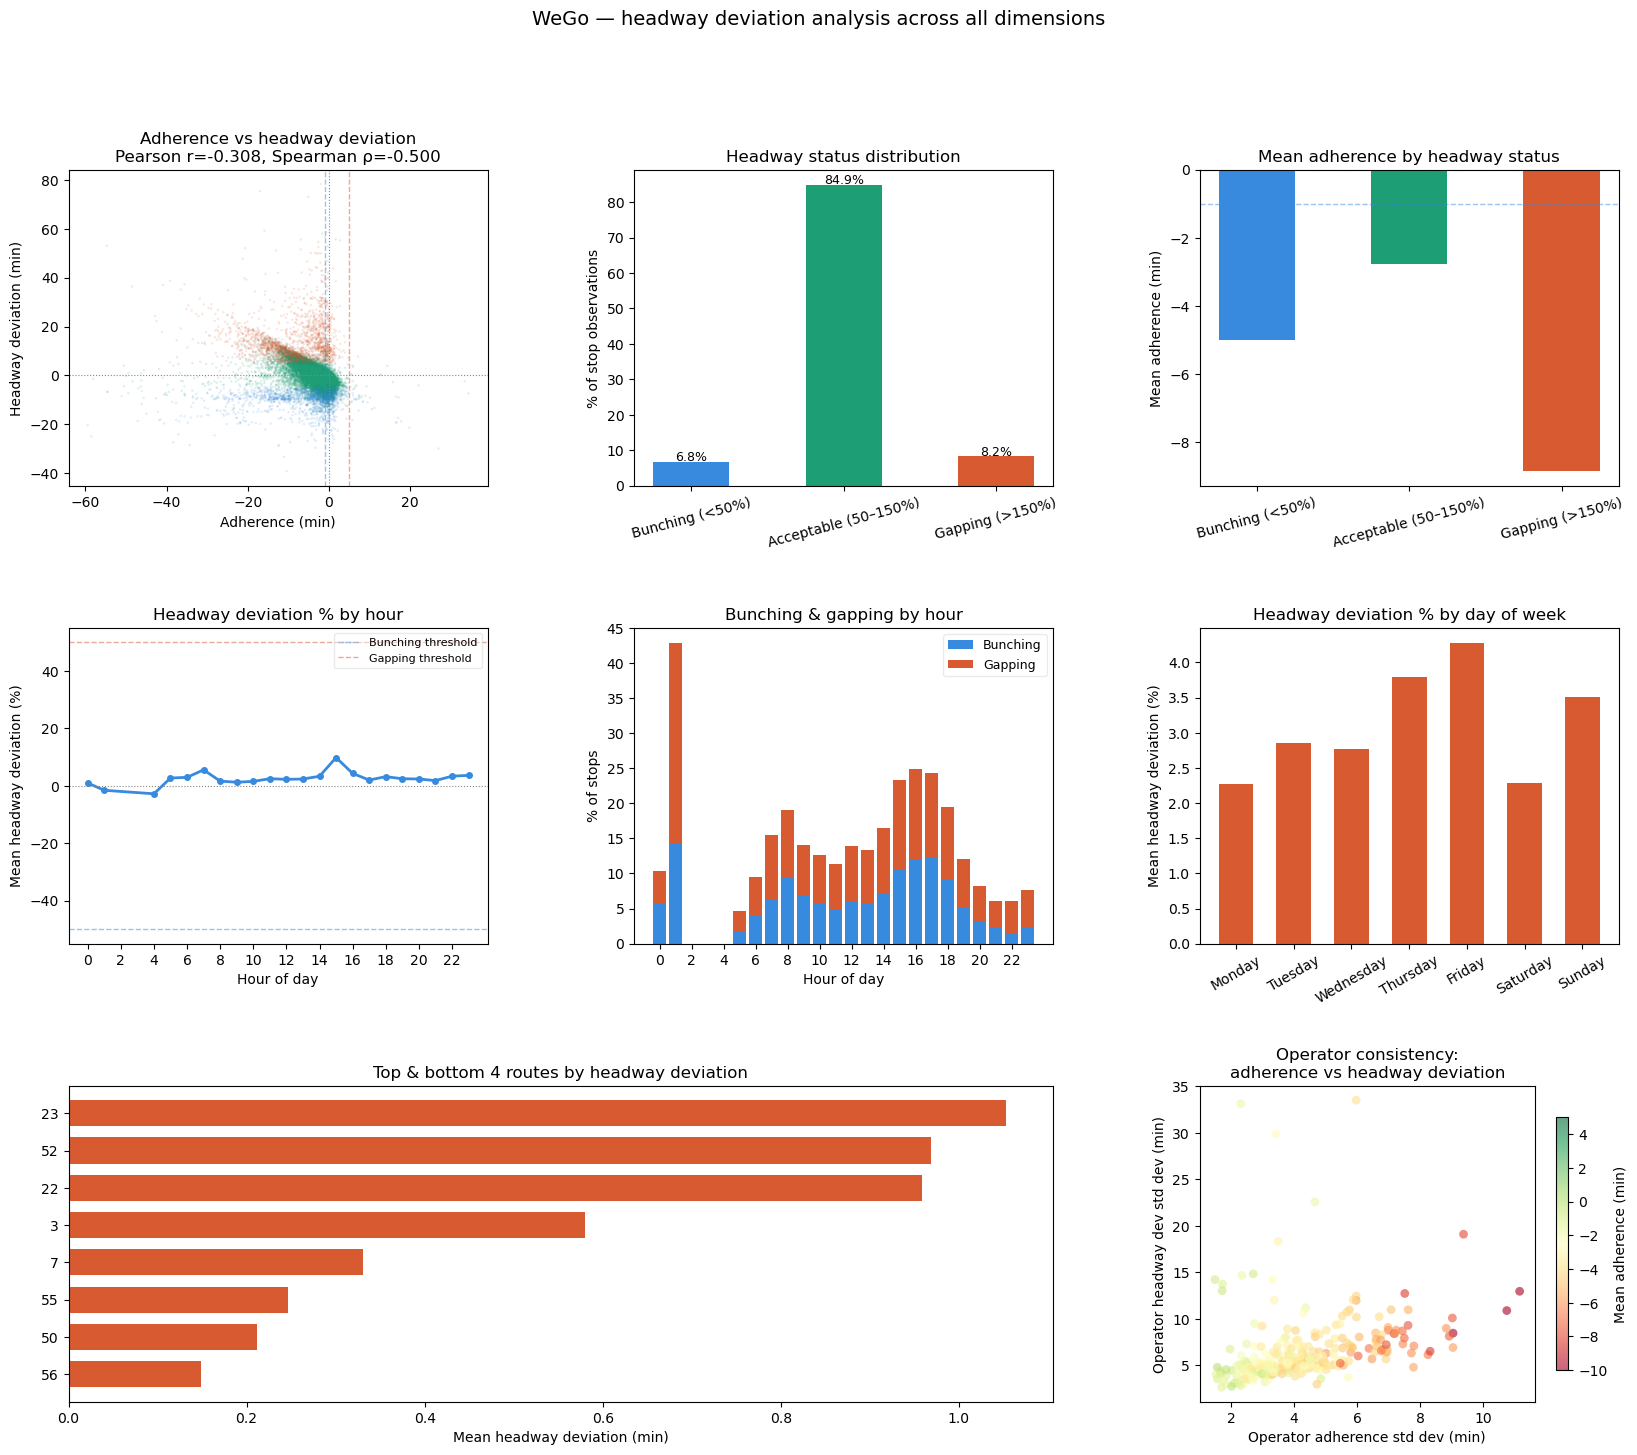

In [32]:

from scipy import stats

early_thresh = -1
late_thresh  =  5

wego_clean = wego[wego["ADHERENCE"].between(-60, 60)].copy()

# ── Headway deviation setup ───────────────────────────────────────────────────
wego_clean = wego_clean[wego_clean["SCHEDULED_HDWY"] > 0].copy()  # drop zero/null hdwy
wego_clean["HDWY_DEV_PCT"] = wego_clean["HDWY_DEV"] / wego_clean["SCHEDULED_HDWY"] * 100
wego_clean["HDWY_STATUS"]  = pd.cut(
    wego_clean["HDWY_DEV_PCT"],
    bins=[-np.inf, -50, 50, np.inf],   # <50% = bunching, 50-150% = ok, >150% = gapping
    labels=["Bunching (<50%)", "Acceptable (50–150%)", "Gapping (>150%)"]
)

total = len(wego_clean)
print("── Headway deviation overview ────────────────────────────")
print(wego_clean["HDWY_STATUS"].value_counts().to_string())
print(f"\nBunching  : {(wego_clean['HDWY_DEV_PCT'] < -50).sum() / total:.1%}")
print(f"Acceptable: {wego_clean['HDWY_DEV_PCT'].between(-50, 50).sum() / total:.1%}")
print(f"Gapping   : {(wego_clean['HDWY_DEV_PCT'] > 50).sum() / total:.1%}")
print(f"\nMean HDWY_DEV     : {wego_clean['HDWY_DEV'].mean():.2f} min")
print(f"Mean HDWY_DEV_PCT : {wego_clean['HDWY_DEV_PCT'].mean():.1f}%")

# ── Correlation: adherence vs headway deviation ───────────────────────────────
# Trim extreme hdwy outliers for cleaner analysis
hw = wego_clean[wego_clean["HDWY_DEV_PCT"].between(-200, 200)].copy()
r, p = stats.pearsonr(hw["ADHERENCE"], hw["HDWY_DEV"])
rho, p2 = stats.spearmanr(hw["ADHERENCE"], hw["HDWY_DEV"])
print(f"\n── Adherence vs HDWY_DEV correlation ─────────────────────")
print(f"  Pearson r  : {r:.3f}  (p={p:.2e})")
print(f"  Spearman ρ : {rho:.3f}  (p={p2:.2e})")

# ── Parse time for temporal analysis ─────────────────────────────────────────
wego_clean["SCHEDULED_TIME"] = pd.to_datetime(wego_clean["SCHEDULED_TIME"])
wego_clean["hour"]    = wego_clean["SCHEDULED_TIME"].dt.hour
wego_clean["dow_name"] = wego_clean["SCHEDULED_TIME"].dt.day_name()

dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

def hdwy_stats(group):
    n = len(group)
    pct = group["HDWY_DEV_PCT"]
    return pd.Series({
        "n":           n,
        "mean_dev":    group["HDWY_DEV"].mean(),
        "mean_pct":    pct.mean(),
        "bunching_pct": (pct < -50).sum() / n * 100,
        "gapping_pct":  (pct >  50).sum() / n * 100,
        "acceptable_pct": pct.between(-50, 50).sum() / n * 100,
    })

hour_hw  = wego_clean.groupby("hour").apply(hdwy_stats, include_groups=False).reset_index()
dow_hw   = wego_clean.groupby("dow_name").apply(hdwy_stats, include_groups=False).reset_index()
dow_hw["dow_name"] = pd.Categorical(dow_hw["dow_name"], categories=dow_order, ordered=True)
dow_hw   = dow_hw.sort_values("dow_name")
route_hw = (
    wego_clean.groupby("ROUTE_ABBR").apply(hdwy_stats, include_groups=False)
    .reset_index().query("n >= 50").sort_values("mean_dev")
)
op_hw = (
    wego_clean.groupby("OPERATOR").apply(hdwy_stats, include_groups=False)
    .reset_index().query("n >= 50")
)

# ── Plots ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
gs  = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# — 1. Scatter: adherence vs HDWY_DEV (sampled)
ax = fig.add_subplot(gs[0, 0])
samp = hw.sample(min(30_000, len(hw)), random_state=42)
c = np.where(samp["HDWY_DEV_PCT"] < -50, "#378ADD",
    np.where(samp["HDWY_DEV_PCT"] >  50, "#D85A30", "#1D9E75"))
ax.scatter(samp["ADHERENCE"], samp["HDWY_DEV"], c=c, alpha=0.15, s=3, linewidths=0)
ax.axhline(0, color="#888780", lw=0.8, ls=":")
ax.axvline(0, color="#888780", lw=0.8, ls=":")
ax.axvline(early_thresh, color="#378ADD", lw=1, ls="--", alpha=0.5)
ax.axvline(late_thresh,  color="#D85A30", lw=1, ls="--", alpha=0.5)
ax.set_xlabel("Adherence (min)")
ax.set_ylabel("Headway deviation (min)")
ax.set_title(f"Adherence vs headway deviation\nPearson r={r:.3f}, Spearman ρ={rho:.3f}",
             fontweight="medium")

# — 2. Headway status breakdown (pie/bar)
ax = fig.add_subplot(gs[0, 1])
status_counts = wego_clean["HDWY_STATUS"].value_counts().reindex(
    ["Bunching (<50%)", "Acceptable (50–150%)", "Gapping (>150%)"])
colors_hw = ["#378ADD", "#1D9E75", "#D85A30"]
ax.bar(status_counts.index, status_counts.values / total * 100,
       color=colors_hw, width=0.5)
ax.set_ylabel("% of stop observations")
ax.set_title("Headway status distribution", fontweight="medium")
ax.tick_params(axis="x", rotation=15)
for i, (v, n) in enumerate(zip(status_counts.values / total * 100, status_counts.values)):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

# — 3. Adherence mean by headway status
ax = fig.add_subplot(gs[0, 2])
adh_by_status = wego_clean.groupby("HDWY_STATUS", observed=True)["ADHERENCE"].mean()
colors_s = ["#378ADD", "#1D9E75", "#D85A30"]
ax.bar(adh_by_status.index, adh_by_status.values, color=colors_s, width=0.5)
ax.axhline(0, color="#888780", lw=0.8, ls=":")
ax.axhline(early_thresh, color="#378ADD", lw=1, ls="--", alpha=0.5)
ax.set_ylabel("Mean adherence (min)")
ax.set_title("Mean adherence by headway status", fontweight="medium")
ax.tick_params(axis="x", rotation=15)

# — 4. Hourly headway deviation
ax = fig.add_subplot(gs[1, 0])
ax.plot(hour_hw["hour"], hour_hw["mean_pct"], color="#378ADD",
        lw=2, marker="o", ms=4)
ax.axhline(0,   color="#888780", lw=0.8, ls=":")
ax.axhline(-50, color="#378ADD", lw=1,   ls="--", alpha=0.5, label="Bunching threshold")
ax.axhline(50,  color="#D85A30", lw=1,   ls="--", alpha=0.5, label="Gapping threshold")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean headway deviation (%)")
ax.set_title("Headway deviation % by hour", fontweight="medium")
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=8, framealpha=0.4)

# — 5. Stacked bunching/gapping by hour
ax = fig.add_subplot(gs[1, 1])
ax.bar(hour_hw["hour"], hour_hw["bunching_pct"],
       color="#378ADD", label="Bunching", width=0.8)
ax.bar(hour_hw["hour"], hour_hw["gapping_pct"],
       bottom=hour_hw["bunching_pct"],
       color="#D85A30", label="Gapping", width=0.8)
ax.set_xlabel("Hour of day")
ax.set_ylabel("% of stops")
ax.set_title("Bunching & gapping by hour", fontweight="medium")
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=9, framealpha=0.4)

# — 6. Day of week headway deviation
ax = fig.add_subplot(gs[1, 2])
colors_dow = ["#378ADD" if v < 0 else "#D85A30" for v in dow_hw["mean_pct"]]
ax.bar(dow_hw["dow_name"], dow_hw["mean_pct"], color=colors_dow, width=0.6)
ax.axhline(0, color="#888780", lw=0.8, ls=":")
ax.set_ylabel("Mean headway deviation (%)")
ax.set_title("Headway deviation % by day of week", fontweight="medium")
ax.tick_params(axis="x", rotation=30)

# — 7. Route headway deviation (top/bottom 20)
ax = fig.add_subplot(gs[2, 0:2])
n_show = min(20, len(route_hw) // 2)
show_r = pd.concat([route_hw.head(n_show), route_hw.tail(n_show)]).drop_duplicates()
colors_r = ["#378ADD" if v < 0 else "#D85A30" for v in show_r["mean_dev"]]
ax.barh(show_r["ROUTE_ABBR"].astype(str), show_r["mean_dev"],
        color=colors_r, height=0.7)
ax.axvline(0, color="#888780", lw=0.8, ls=":")
ax.set_xlabel("Mean headway deviation (min)")
ax.set_title(f"Top & bottom {n_show} routes by headway deviation", fontweight="medium")

# — 8. Operator: adherence std vs headway deviation std
ax = fig.add_subplot(gs[2, 2])
op_merge = (
    wego_clean.groupby("OPERATOR")
    .agg(adh_mean=("ADHERENCE","mean"), adh_std=("ADHERENCE","std"),
         hdwy_std=("HDWY_DEV","std"), n=("ADHERENCE","count"))
    .query("n >= 50")
    .reset_index()
)
sc = ax.scatter(op_merge["adh_std"], op_merge["hdwy_std"],
                c=op_merge["adh_mean"], cmap="RdYlGn", vmin=-10, vmax=5,
                s=40, alpha=0.6, linewidths=0)
plt.colorbar(sc, ax=ax, label="Mean adherence (min)", shrink=0.8)
ax.set_xlabel("Operator adherence std dev (min)")
ax.set_ylabel("Operator headway dev std dev (min)")
ax.set_title("Operator consistency:\nadherence vs headway deviation", fontweight="medium")

fig.suptitle("WeGo — headway deviation analysis across all dimensions",
             fontsize=14, fontweight="medium")
plt.savefig("wego_headway_analysis.png", dpi=150, bbox_inches="tight")
plt.show()